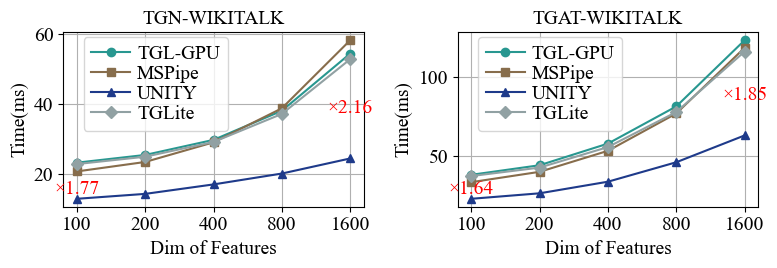

In [25]:
import yaml
import matplotlib.pyplot as plt
import numpy as np
import re

plt.rcParams['font.family'] = 'Times New Roman'
plt.rc('font', size=14)
plt.rc('axes', titlesize=14)

# 读取 dim_feat.yaml
with open('dim_feat.yaml', 'r') as file:
    data = yaml.load(file, Loader=yaml.FullLoader)

# 维度数值（按此顺序绘图）
dim_nums = [100, 200, 400, 800, 1600]
# X轴显示为字符串
dimensions = [str(x) for x in dim_nums]

def pick_value_by_dim(d: dict, n: int):
    """在 d 中按维度数值 n 寻找对应 value。
    依次尝试：'D{n}', 'B{n}', n(整型), '{n}'(字符串)；若都不在，再用正则匹配末尾数字 == n 的键。
    """
    # 直接命中常见前缀
    for k in (f'D{n}', f'B{n}', n, str(n)):
        if k in d:
            return d[k]
    # 正则兜底：找末尾数字等于 n 的键（兼容更复杂前缀）
    for k, v in d.items():
        if isinstance(k, str):
            m = re.search(r'(\d+)$', k)
            if m and int(m.group(1)) == n:
                return v
    raise KeyError(f"Cannot find value for dimension {n} in keys: {list(d.keys())}")

def to_series(d: dict):
    return [pick_value_by_dim(d, n) for n in dim_nums]

# ---------- 提取数据 ----------
# TGN
tgn_tgl     = to_series(data['WIKITALK']['TGN']['TGL'])
tgn_mspipe  = to_series(data['WIKITALK']['TGN']['MSPipe'])
tgn_unity   = to_series(data['WIKITALK']['TGN']['UNITY'])
tgn_tglite  = to_series(data['WIKITALK']['TGN']['TGLite'])  # 新增

# TGAT
tgat_tgl    = to_series(data['WIKITALK']['TGAT']['TGL'])
tgat_mspipe = to_series(data['WIKITALK']['TGAT']['MSPipe'])
tgat_unity  = to_series(data['WIKITALK']['TGAT']['UNITY'])
tgat_tglite = to_series(data['WIKITALK']['TGAT']['TGLite']) # 新增

# 倍数差（保持你原先仅对 TGL 相对 UNITY 做标注）
def get_multiplicative_diff(arr, unity_arr):
    return [a / unity_arr[i] for i, a in enumerate(arr)]

tgn_tgl_diff  = get_multiplicative_diff(tgn_tglite,  tgn_unity)
tgat_tgl_diff = get_multiplicative_diff(tgat_tglite, tgat_unity)

# ---------- 画图 ----------
fig, axes = plt.subplots(1, 2, figsize=(8, 2.9))

# TGN 子图
axes[0].plot(dimensions, tgn_tgl,     label='TGL-GPU', marker='o', color='#289790')
axes[0].plot(dimensions, tgn_mspipe,  label='MSPipe',  marker='s', color='#876d4c')
axes[0].plot(dimensions, tgn_unity,   label='UNITY',   marker='^', color='#1E3A8A')
axes[0].plot(dimensions, tgn_tglite,  label='TGLite',  marker='D', color='#91a1a3')

# 在 D100、D1600 标注 TGL/UNITY 倍数
for i in [0, 4]:
    y = tgn_tgl[i]
    dy = 10 if i == 0 else 18
    axes[0].text(dimensions[i], y - dy, f'×{tgn_tgl_diff[i]:.2f}',
                 ha='center', va='bottom', color='red')

axes[0].set_title('TGN-WIKITALK')
axes[0].set_xlabel('Dim of Features')
axes[0].set_ylabel('Time(ms)')
axes[0].grid(True)
axes[0].legend(labelspacing=0.1, bbox_to_anchor=(0.58, 0.38), handletextpad=0.35)

# TGAT 子图
axes[1].plot(dimensions, tgat_tgl,     label='TGL-GPU', marker='o', color='#289790')
axes[1].plot(dimensions, tgat_mspipe,  label='MSPipe',  marker='s', color='#876d4c')
axes[1].plot(dimensions, tgat_unity,   label='UNITY',   marker='^', color='#1E3A8A')
axes[1].plot(dimensions, tgat_tglite,  label='TGLite',  marker='D', color='#91a1a3') 

for i in [0, 4]:
    if i == 0:
        axes[1].text(dimensions[i], tgat_tgl[i] - 15,
                     f'×{tgat_tgl_diff[i]:.2f}', ha='center', va='bottom', color='red')
    else:
        axes[1].text(dimensions[i], (tgat_tgl[i] + tgat_unity[i]) / 2 - 10,
                     f'×{tgat_tgl_diff[i]:.2f}', ha='center', va='bottom', color='red')

axes[1].set_title('TGAT-WIKITALK')
axes[1].set_xlabel('Dim of Features')
axes[1].set_ylabel('Time(ms)')
axes[1].grid(True)
axes[1].legend(labelspacing=0.1, bbox_to_anchor=(0.58, 0.38), handletextpad=0.35)

plt.tight_layout()
plt.savefig('exp4.pdf', bbox_inches='tight')
plt.show()
